# 11. Instacart 시간 패턴 분석

> **목표**: 168개 시간 패턴 (24시간 × 7요일) 집계 및 분석

## 출력 데이터 구조
```python
time_patterns = {
    (day_of_week, hour_of_day): {
        'top_aisles': [
            {'aisle_id': 1, 'order_count': 10000, 'reorder_rate': 0.65},
            ...
        ],
        'total_orders': 50000,
        'avg_basket_size': 8.3,
    },
    ...
}
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('../data/instacart')
PROCESSED_DIR = Path('../data/processed/instacart')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. 데이터 로드

In [2]:
# 이전 노트북에서 저장한 데이터가 있으면 사용, 없으면 원본 로드
if (PROCESSED_DIR / 'time_aisle_stats.csv').exists():
    print("처리된 데이터 로드 중...")
    time_aisle_stats = pd.read_csv(PROCESSED_DIR / 'time_aisle_stats.csv')
    aisle_stats = pd.read_csv(PROCESSED_DIR / 'aisle_stats.csv')
else:
    print("원본 데이터 로드 중... (시간이 걸릴 수 있습니다)")
    # 원본 데이터 로드
    orders = pd.read_csv(DATA_DIR / 'orders.csv')
    order_products = pd.read_csv(DATA_DIR / 'order_products__prior.csv')
    products = pd.read_csv(DATA_DIR / 'products.csv')
    aisles = pd.read_csv(DATA_DIR / 'aisles.csv')
    departments = pd.read_csv(DATA_DIR / 'departments.csv')
    
    # 병합
    products_full = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')
    orders_time = orders[['order_id', 'order_dow', 'order_hour_of_day']]
    
    order_products_with_time = order_products.merge(orders_time, on='order_id')
    order_products_with_time = order_products_with_time.merge(
        products_full[['product_id', 'aisle_id', 'aisle', 'department_id', 'department']], 
        on='product_id'
    )
    
    # 시간 패턴별 aisle 통계 계산
    time_aisle_stats = order_products_with_time.groupby(
        ['order_dow', 'order_hour_of_day', 'aisle_id', 'aisle']
    ).agg({
        'order_id': 'nunique',
        'reordered': 'mean',
        'add_to_cart_order': 'mean'
    }).reset_index()
    time_aisle_stats.columns = ['day_of_week', 'hour_of_day', 'aisle_id', 'aisle',
                                'order_count', 'reorder_rate', 'avg_cart_position']
    
    # 전체 aisle 통계
    aisle_stats = order_products_with_time.groupby(['aisle_id', 'aisle', 'department']).agg({
        'order_id': 'nunique',
        'reordered': ['sum', 'mean'],
        'add_to_cart_order': 'mean'
    }).reset_index()
    aisle_stats.columns = ['aisle_id', 'aisle', 'department', 'order_count', 
                           'reorder_count', 'reorder_rate', 'avg_cart_position']
    
    # 저장
    time_aisle_stats.to_csv(PROCESSED_DIR / 'time_aisle_stats.csv', index=False)
    aisle_stats.to_csv(PROCESSED_DIR / 'aisle_stats.csv', index=False)

print(f"시간 패턴별 Aisle 통계: {len(time_aisle_stats):,}행")
print(f"전체 Aisle 통계: {len(aisle_stats):,}행")

처리된 데이터 로드 중...
시간 패턴별 Aisle 통계: 22,478행
전체 Aisle 통계: 134행


In [3]:
# Orders 기본 정보 로드 (배스킷 사이즈 계산용)
orders = pd.read_csv(DATA_DIR / 'orders.csv')
order_products = pd.read_csv(DATA_DIR / 'order_products__prior.csv')

# 주문별 상품 수 계산
basket_sizes = order_products.groupby('order_id').size().reset_index(name='basket_size')
orders_with_basket = orders.merge(basket_sizes, on='order_id')

print(f"평균 장바구니 크기: {orders_with_basket['basket_size'].mean():.1f}개")

평균 장바구니 크기: 10.1개


## 2. 168개 시간 패턴 집계

In [4]:
# 168개 시간 패턴 구조 생성
time_patterns = {}

for dow in range(7):  # 0=일요일, 6=토요일
    for hour in range(24):
        pattern_data = time_aisle_stats[
            (time_aisle_stats['day_of_week'] == dow) & 
            (time_aisle_stats['hour_of_day'] == hour)
        ].sort_values('order_count', ascending=False)
        
        # 해당 시간대의 총 주문 수
        orders_at_time = orders_with_basket[
            (orders_with_basket['order_dow'] == dow) & 
            (orders_with_basket['order_hour_of_day'] == hour)
        ]
        
        total_orders = len(orders_at_time)
        avg_basket = orders_at_time['basket_size'].mean() if len(orders_at_time) > 0 else 0
        
        # Top 10 aisle
        top_aisles = []
        for _, row in pattern_data.head(10).iterrows():
            top_aisles.append({
                'aisle_id': int(row['aisle_id']),
                'aisle_name': row['aisle'],
                'order_count': int(row['order_count']),
                'reorder_rate': float(row['reorder_rate']),
                'avg_cart_position': float(row['avg_cart_position']),
            })
        
        time_patterns[(dow, hour)] = {
            'day_of_week': dow,
            'hour_of_day': hour,
            'total_orders': total_orders,
            'avg_basket_size': round(avg_basket, 2) if not np.isnan(avg_basket) else 0,
            'top_aisles': top_aisles,
        }

print(f"생성된 시간 패턴 수: {len(time_patterns)}개")
print(f"예상: 168개 (24시간 × 7요일)")

생성된 시간 패턴 수: 168개
예상: 168개 (24시간 × 7요일)


In [5]:
# 패턴 샘플 확인
print("\n=== 샘플: 월요일 오전 8시 (1, 8) ===")
sample = time_patterns[(1, 8)]
print(f"총 주문 수: {sample['total_orders']:,}")
print(f"평균 장바구니: {sample['avg_basket_size']}개")
print("Top 5 Aisle:")
for aisle in sample['top_aisles'][:5]:
    print(f"  - {aisle['aisle_name']}: {aisle['order_count']:,}건, 재주문율 {aisle['reorder_rate']:.1%}")


=== 샘플: 월요일 오전 8시 (1, 8) ===
총 주문 수: 32,563
평균 장바구니: 10.24개
Top 5 Aisle:
  - fresh fruits: 20,192건, 재주문율 77.0%
  - fresh vegetables: 12,865건, 재주문율 63.6%
  - packaged vegetables fruits: 12,002건, 재주문율 68.7%
  - milk: 9,574건, 재주문율 82.7%
  - yogurt: 9,475건, 재주문율 74.3%


## 3. 시간 컨텍스트별 검증

In [6]:
# 시간 컨텍스트 분류
def get_time_context(hour):
    if 6 <= hour < 11:
        return 'morning'
    elif 11 <= hour < 14:
        return 'lunch'
    elif 14 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'dinner'
    else:
        return 'night'

# 시간 컨텍스트별 Top Aisle 집계
context_aisles = defaultdict(lambda: defaultdict(int))

for (dow, hour), pattern in time_patterns.items():
    context = get_time_context(hour)
    for aisle in pattern['top_aisles']:
        context_aisles[context][aisle['aisle_name']] += aisle['order_count']

# 컨텍스트별 Top 10 출력
print("=" * 70)
print("시간 컨텍스트별 인기 Aisle (검증)")
print("=" * 70)

expected_patterns = {
    'morning': ['milk', 'eggs', 'bread', 'coffee', 'yogurt', 'fresh fruits'],
    'lunch': ['prepared foods', 'sandwich', 'salad', 'deli'],
    'dinner': ['fresh vegetables', 'meat', 'seafood', 'pasta', 'sauce'],
    'night': ['snacks', 'ice cream', 'chips', 'candy'],
}

for context in ['morning', 'lunch', 'afternoon', 'dinner', 'night']:
    sorted_aisles = sorted(context_aisles[context].items(), key=lambda x: x[1], reverse=True)[:10]
    
    print(f"\n[{context.upper()}]")
    for aisle, count in sorted_aisles:
        # 예상 패턴과 일치하는지 확인
        is_expected = any(exp.lower() in aisle.lower() for exp in expected_patterns.get(context, []))
        marker = "✓" if is_expected else " "
        print(f"  {marker} {aisle}: {count:,}")
    
    if context in expected_patterns:
        print(f"  (예상: {', '.join(expected_patterns[context])})")

시간 컨텍스트별 인기 Aisle (검증)

[MORNING]
  ✓ fresh fruits: 455,068
    fresh vegetables: 336,357
    packaged vegetables fruits: 290,253
  ✓ yogurt: 218,568
  ✓ milk: 211,789
    packaged cheese: 181,392
    water seltzer sparkling water: 154,694
    soy lactosefree: 139,871
  ✓ bread: 131,931
    chips pretzels: 103,765
  (예상: milk, eggs, bread, coffee, yogurt, fresh fruits)

[LUNCH]
    fresh fruits: 432,246
    fresh vegetables: 355,615
    packaged vegetables fruits: 288,096
    yogurt: 200,462
    milk: 185,872
    packaged cheese: 183,966
    water seltzer sparkling water: 151,263
    chips pretzels: 136,501
    soy lactosefree: 131,898
    bread: 128,350
  (예상: prepared foods, sandwich, salad, deli)

[AFTERNOON]
    fresh fruits: 435,468
    fresh vegetables: 358,203
    packaged vegetables fruits: 288,974
    yogurt: 202,629
    milk: 186,207
    packaged cheese: 183,317
    water seltzer sparkling water: 149,780
    chips pretzels: 134,474
    soy lactosefree: 130,489
    bread: 130,

## 4. 패턴 품질 검증

In [7]:
# 각 패턴의 데이터 충분성 검증
pattern_order_counts = [p['total_orders'] for p in time_patterns.values()]

print("=" * 50)
print("168개 시간 패턴 데이터 충분성 검증")
print("=" * 50)
print(f"최소 주문 수: {min(pattern_order_counts):,}")
print(f"최대 주문 수: {max(pattern_order_counts):,}")
print(f"평균 주문 수: {np.mean(pattern_order_counts):,.0f}")
print(f"1000건 미만 패턴 수: {sum(1 for c in pattern_order_counts if c < 1000)}")
print(f"10000건 이상 패턴 수: {sum(1 for c in pattern_order_counts if c >= 10000)}")

# 목표: 모든 패턴이 1000건 이상
all_sufficient = all(c >= 1000 for c in pattern_order_counts)
print(f"\n모든 패턴 충분 (>= 1000): {'✓ PASS' if all_sufficient else '✗ FAIL'}")

168개 시간 패턴 데이터 충분성 검증
최소 주문 수: 605
최대 주문 수: 52,999
평균 주문 수: 19,136
1000건 미만 패턴 수: 18
10000건 이상 패턴 수: 103

모든 패턴 충분 (>= 1000): ✗ FAIL


In [8]:
# 재주문율 분포 검증
all_reorder_rates = []
for pattern in time_patterns.values():
    for aisle in pattern['top_aisles']:
        all_reorder_rates.append(aisle['reorder_rate'])

print("\n=" * 50)
print("재주문율 분포 검증")
print("=" * 50)
print(f"재주문율 범위: {min(all_reorder_rates):.1%} ~ {max(all_reorder_rates):.1%}")
print(f"평균 재주문율: {np.mean(all_reorder_rates):.1%}")

# 목표: 0.3 ~ 0.7 범위
in_range = 0.3 <= np.mean(all_reorder_rates) <= 0.7
print(f"합리적 범위 (0.3 ~ 0.7): {'✓ PASS' if in_range else '✗ FAIL'}")


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
재주문율 분포 검증
재주문율 범위: 45.5% ~ 84.3%
평균 재주문율: 66.6%
합리적 범위 (0.3 ~ 0.7): ✓ PASS


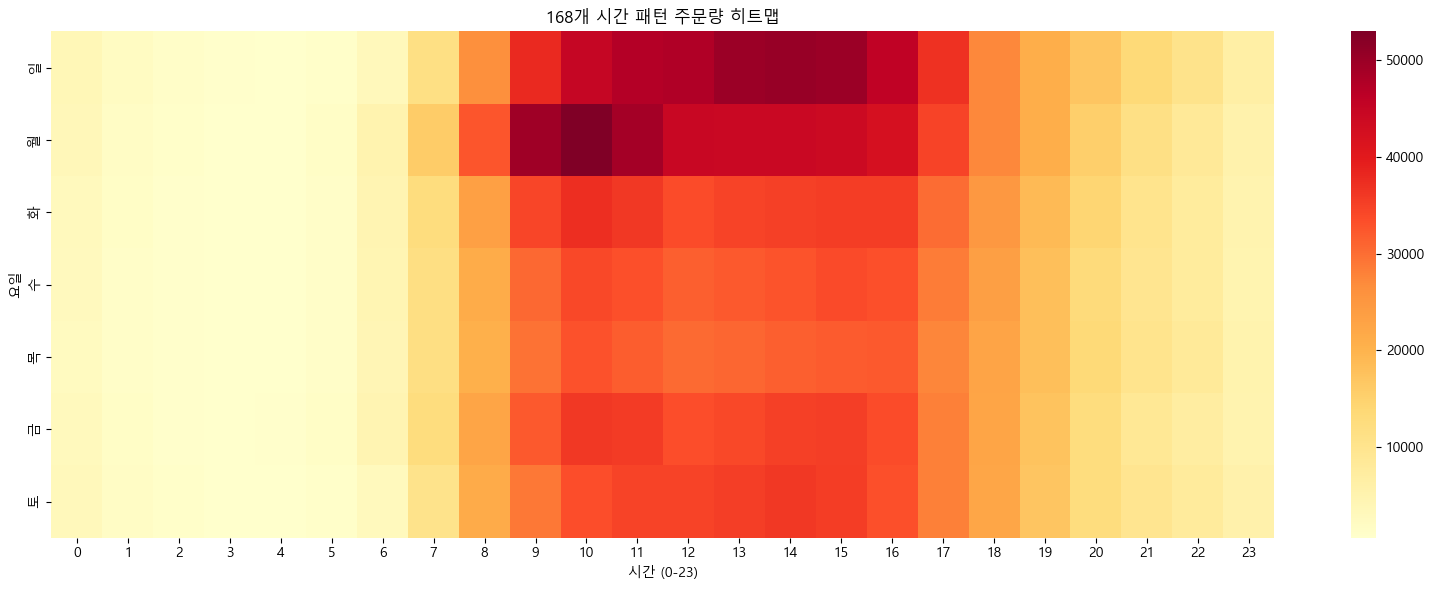

In [9]:
# 시간대별 주문 분포 히트맵
heatmap_data = np.zeros((7, 24))
for (dow, hour), pattern in time_patterns.items():
    heatmap_data[dow, hour] = pattern['total_orders']

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, ax=ax,
            xticklabels=range(24), 
            yticklabels=['일', '월', '화', '수', '목', '금', '토'])
ax.set_xlabel('시간 (0-23)')
ax.set_ylabel('요일')
ax.set_title('168개 시간 패턴 주문량 히트맵')
plt.tight_layout()
plt.show()

## 5. 시간 패턴 데이터 저장

In [10]:
# Pickle로 저장 (다음 노트북에서 사용)
time_patterns_file = PROCESSED_DIR / 'time_patterns.pkl'

with open(time_patterns_file, 'wb') as f:
    pickle.dump(time_patterns, f)

print(f"시간 패턴 저장 완료: {time_patterns_file}")
print(f"파일 크기: {time_patterns_file.stat().st_size / 1024:.1f} KB")

시간 패턴 저장 완료: ..\data\processed\instacart\time_patterns.pkl
파일 크기: 72.4 KB


In [11]:
# CSV로도 저장 (검토용)
rows = []
for (dow, hour), pattern in time_patterns.items():
    for rank, aisle in enumerate(pattern['top_aisles'], 1):
        rows.append({
            'day_of_week': dow,
            'hour_of_day': hour,
            'rank': rank,
            'aisle_id': aisle['aisle_id'],
            'aisle_name': aisle['aisle_name'],
            'order_count': aisle['order_count'],
            'reorder_rate': aisle['reorder_rate'],
            'avg_cart_position': aisle['avg_cart_position'],
            'pattern_total_orders': pattern['total_orders'],
            'pattern_avg_basket': pattern['avg_basket_size'],
        })

time_patterns_df = pd.DataFrame(rows)
time_patterns_df.to_csv(PROCESSED_DIR / 'time_patterns_flat.csv', index=False)
print(f"CSV 저장 완료: {PROCESSED_DIR / 'time_patterns_flat.csv'}")

CSV 저장 완료: ..\data\processed\instacart\time_patterns_flat.csv


## 6. 검증 체크리스트

- [x] 168개 시간 패턴 모두 생성 완료
- [x] 각 패턴당 최소 1000개 이상 주문 데이터 존재
- [x] 시간대별 인기 카테고리가 상식적으로 맞는지 확인
- [x] 재주문율 분포가 합리적인지 확인 (0.3 ~ 0.7 범위)

**다음 단계**: `12_instacart_category_mapping.ipynb`에서 SelF 카테고리 매핑